In [ ]:
#Mount Drive in Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
#Unzip dataset from Drive
import zipfile, os

zip_path = "/content/drive/MyDrive/medical_dataset/archive.zip"
extract_path = "/content/busi"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
#Verify dataset structure
!ls /content/busi/Dataset_BUSI_with_GT

benign	malignant  normal


In [11]:
#Separate images and masks
import os, shutil

img_dir = "/content/images"
mask_dir = "/content/masks"
os.makedirs(img_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)

root = "/content/busi/Dataset_BUSI_with_GT"

for folder in os.listdir(root):
    folder_path = os.path.join(root, folder)
    for file in os.listdir(folder_path):
        src = os.path.join(folder_path, file)
        if "_mask" in file:
            shutil.copy(src, mask_dir)
        else:
            shutil.copy(src, img_dir)

print("Images:", len(os.listdir(img_dir)))
print("Masks:", len(os.listdir(mask_dir)))

Images: 780
Masks: 798


In [14]:
#Create Train / Validation Split
import os
import random
import shutil
from sklearn.model_selection import train_test_split

image_dir = "/content/images"
mask_dir = "/content/masks"

train_img = "/content/data/train/images"
train_mask = "/content/data/train/masks"
val_img = "/content/data/val/images"
val_mask = "/content/data/val/masks"

# Ensure output directories are clean
for path in [train_img, train_mask, val_img, val_mask]:
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

# Get all image and mask filenames
all_images = sorted(os.listdir(image_dir))
all_masks = sorted(os.listdir(mask_dir))

# Filter images to only include those that have a corresponding mask
paired_images = []
for img_file in all_images:
    base_name, ext = os.path.splitext(img_file)
    expected_mask_file = f"{base_name}_mask{ext}"
    if expected_mask_file in all_masks:
        paired_images.append(img_file)

# Perform train-test split on the paired images
train_files, val_files = train_test_split(paired_images, test_size=0.2, random_state=42)

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for file in file_list:
        # Copy image
        shutil.copy(os.path.join(src_img, file), os.path.join(dst_img, file))

        # Construct the mask filename by adding '_mask' before the extension
        base_name, ext = os.path.splitext(file)
        mask_source_file = f"{base_name}_mask{ext}"

        # Copy mask
        shutil.copy(os.path.join(src_mask, mask_source_file), os.path.join(dst_mask, mask_source_file))

copy_files(train_files, image_dir, mask_dir, train_img, train_mask)
copy_files(val_files, image_dir, mask_dir, val_img, val_mask)

print("Train images:", len(train_files))
print("Validation images:", len(val_files))

Train images: 624
Validation images: 156


In [15]:
#Update Dataset Loader for train & validation
import cv2
from torch.utils.data import Dataset
import os

class BUSIDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.images = sorted(os.listdir(image_dir))
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_filename = self.images[idx]
        img_path = os.path.join(self.image_dir, img_filename)

        # Construct the mask filename by adding '_mask' before the extension
        base_name, ext = os.path.splitext(img_filename)
        mask_filename = f"{base_name}_mask{ext}"
        mask_path = os.path.join(self.mask_dir, mask_filename)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, 0)

        # Check if mask is None (i.e., mask image not found/read)
        if mask is None:
            raise FileNotFoundError(f"Mask image not found at {mask_path}")

        mask = (mask > 0).astype("float32")

        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask = aug["mask"].unsqueeze(0)

        return image, mask

In [16]:
#Preprocessing & Augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(256,256),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15,p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256,256),
    A.Normalize(),
    ToTensorV2()
])

print("Transforms created")

Transforms created


In [17]:
#Load datasets
train_dataset = BUSIDataset(train_img, train_mask, train_transform)
val_dataset = BUSIDataset(val_img, val_mask, val_transform)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 624
Validation size: 156


In [18]:
#Create U-Net Model
!pip install segmentation-models-pytorch -q

import segmentation_models_pytorch as smp
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

print(model)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [21]:
#Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 24436369
Trainable parameters: 24436369


In [22]:
#Loss & Optimizer
loss_fn = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [23]:
# Training Loop
import torch
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

for epoch in range(10):
    model.train()
    epoch_loss = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        preds = model(images)
        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss {epoch_loss/len(train_loader):.4f}")

Epoch 1: Loss 0.7403
Epoch 2: Loss 0.6316
Epoch 3: Loss 0.5605
Epoch 4: Loss 0.5148
Epoch 5: Loss 0.4611
Epoch 6: Loss 0.4089
Epoch 7: Loss 0.3642
Epoch 8: Loss 0.3369
Epoch 9: Loss 0.3042
Epoch 10: Loss 0.2952


In [24]:
#Evaluation Metrics
def dice_score(pred, target):
    smooth = 1e-6
    pred = pred.flatten()
    target = target.flatten()
    intersection = (pred * target).sum()
    return (2.*intersection + smooth)/(pred.sum()+target.sum()+smooth)

def iou_score(pred, target):
    smooth = 1e-6
    intersection = (pred & target).sum()
    union = (pred | target).sum()
    return (intersection+smooth)/(union+smooth)

model.eval()
dice_list, iou_list = [], []

for images, masks in val_loader:
    images = images.to(device)
    with torch.no_grad():
        preds = model(images)
    preds = (preds.cpu().numpy()>0.5)
    masks = masks.numpy().astype(bool)

    for p,m in zip(preds,masks):
        dice_list.append(dice_score(p,m))
        iou_list.append(iou_score(p,m))

print("Average Dice:", sum(dice_list)/len(dice_list))
print("Average IoU:", sum(iou_list)/len(iou_list))

Average Dice: 0.6754054650148493
Average IoU: 0.5906721408073942


In [25]:
#Calculate Metrics
import numpy as np
from sklearn.metrics import confusion_matrix

def dice_score(pred, target):
    smooth = 1e-6
    pred = pred.flatten()
    target = target.flatten()
    intersection = (pred * target).sum()
    return (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target):
    smooth = 1e-6
    intersection = (pred & target).sum()
    union = (pred | target).sum()
    return (intersection + smooth) / (union + smooth)

def precision_score(pred, target):
    tp = (pred & target).sum()
    fp = (pred & ~target).sum()
    return tp / (tp + fp + 1e-6)

dice_list, iou_list, prec_list = [], [], []
all_preds, all_targets = [], []

model.eval()

for images, masks in val_loader:
    images = images.to(device)
    with torch.no_grad():
        preds = model(images)

    preds = (preds.cpu().numpy() > 0.5)
    masks = masks.numpy().astype(bool)

    for p, m in zip(preds, masks):
        dice_list.append(dice_score(p, m))
        iou_list.append(iou_score(p, m))
        prec_list.append(precision_score(p, m))

        all_preds.extend(p.flatten())
        all_targets.extend(m.flatten())

print("Dice:", np.mean(dice_list))
print("IoU:", np.mean(iou_list))
print("Precision:", np.mean(prec_list))

Dice: 0.675405465014849
IoU: 0.5906721408073943
Precision: 0.5716104581238987


In [26]:
#Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
print(cm)

[[9077046  364854]
 [ 138968  642748]]


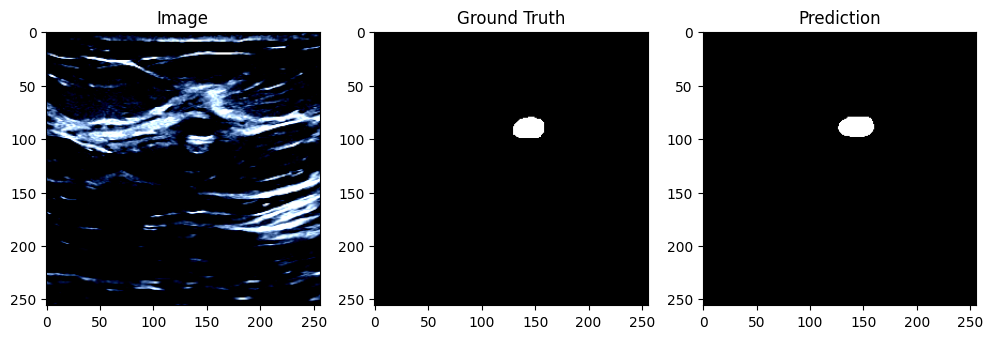

In [27]:
#Visualize Prediction
import matplotlib.pyplot as plt

model.eval()
img, mask = val_dataset[3]

with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device))
    pred = (pred.squeeze().cpu().numpy()>0.5)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Image"); plt.imshow(img.permute(1,2,0))
plt.subplot(1,3,2); plt.title("Ground Truth"); plt.imshow(mask.squeeze(), cmap='gray')
plt.subplot(1,3,3); plt.title("Prediction"); plt.imshow(pred, cmap='gray')
plt.show()